# Métodos numéricos que seran usados en el proyecto

### Splines cúbicos 

In [16]:
def truncar(numero, decimales):
    """
    Trunca un número a un número específico de decimales.
    
    :param numero: El número a truncar
    :param decimales: Cuántos decimales mantener
    :return: Número truncado
    Ejemplo: original=0.335 → truncado=0.33 (2 decimales)
    """
    factor = 10 ** decimales
    return int(numero * factor) / factor

In [17]:
def spline_cubico_natural(x, y, decimales=None):
    """
    Calcula los coeficientes del spline cúbico natural para puntos (x_i, y_i).
    
    :param x: lista de valores x (n+1 puntos)
    :param y: lista de valores y correspondientes
    :param decimales: número de decimales para truncar los coeficientes (opcional)
    :return: listas a, b, c, d para cada tramo j = 0, ..., n-1
    """
    import numpy as np

    # Validaciones iniciales
    if len(x) != len(y):
        raise ValueError("Las listas x e y deben tener la misma longitud.")
    if len(set(x)) != len(x):
        raise ValueError("Los valores de x deben ser únicos para evitar división por cero.")
    if not all(np.isfinite(x)) or not all(np.isfinite(y)):
        raise ValueError("x e y no deben contener NaN ni infinitos.")
    
    # Ordenar los datos por x
    x, y = zip(*sorted(zip(x, y)))
    
    n = len(x) - 1
    h = [x[i+1] - x[i] for i in range(n)]
    
    # Validar que no haya h[i] == 0
    if any(hi == 0 for hi in h):
        raise ZeroDivisionError("Hay intervalos nulos en x, lo que causa división por cero.")

    # Paso 2: calcular alpha
    alpha = [0] * (n+1)
    for i in range(1, n):
        alpha[i] = 3 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])
    
    # Paso 3: inicialización
    l = [1] + [0] * n
    mu = [0] * (n+1)
    z = [0] * (n+1)
    
    # Paso 4: resolver sistema tridiagonal
    for i in range(1, n):
        l[i] = 2 * (x[i+1] - x[i-1]) - h[i-1] * mu[i-1]
        mu[i] = h[i] / l[i]
        z[i] = (alpha[i] - h[i-1] * z[i-1]) / l[i]
    
    # Paso 5: condiciones naturales
    l[n] = 1
    z[n] = 0
    c = [0] * (n+1)
    
    # Paso 6: retro-substitución
    b = [0] * n
    d = [0] * n
    a = [y[j] for j in range(n)]
    
    for j in reversed(range(n)):
        c[j] = z[j] - mu[j] * c[j+1]
        b[j] = (y[j+1] - y[j]) / h[j] - h[j] * (c[j+1] + 2 * c[j]) / 3
        d[j] = (c[j+1] - c[j]) / (3 * h[j])
    
    # Paso 7: truncar decimales
    if decimales is not None:
        truncar = lambda val, d: round(val, d)
        a = [truncar(val, decimales) for val in a]
        b = [truncar(val, decimales) for val in b]
        c = [truncar(val, decimales) for val in c[:n]]
        d = [truncar(val, decimales) for val in d]

    return a, b, c[:n], d

In [3]:
import pandas as pd

datos = pd.read_csv('../Dataset/household_energy_consumption.csv')

# datos con aire 
datos_aire = datos[datos['Has_AC'] == 'Yes']

datos_aire.to_csv('../Dataset/datos_aire.csv', index=False)
datos_aire=datos_aire.dropna()


datos_no_aire = datos[datos['Has_AC'] == 'No']
datos_no_aire = datos_no_aire[['Avg_Temperature_C', 'Energy_Consumption_kWh' ]]
datos_no_aire=datos_no_aire.dropna()
datos_no_aire.to_csv('../Dataset/datos_no_aire.csv', index=False)
#datos_no_aire.isnull().sum()


#atos_aire = datos_aire.drop_duplicates('Energy_Consumption_kWh')
# Promediar solo columnas numéricas para evitar error por columnas tipo object
datos_aire = datos_aire.groupby('Avg_Temperature_C', as_index=False).agg({
	'Energy_Consumption_kWh': 'mean',
	'Household_Size': 'mean',
	'Peak_Hours_Usage_kWh': 'mean'
})
datos_aire.to_csv('../Dataset/datos_aire_limpio.csv', index=False)

#datos_no_aire = datos_no_aire.drop_duplicates('Energy_Consumption_kWh')
datos_no_aire = datos_no_aire.drop_duplicates('Avg_Temperature_C')
datos_no_aire.to_csv('../Dataset/datos_no_aire_limpio.csv', index=False)
# Verificar
print(datos_aire.head())
print("Número de registros después de limpieza:", len(datos_aire))


datos_aire = datos_aire.sort_values('Avg_Temperature_C')
datos_no_aire = datos_no_aire.sort_values('Avg_Temperature_C')

datos_aire.head()
datos_aire.size


   Avg_Temperature_C  Energy_Consumption_kWh  Household_Size  \
0               10.0               12.047619        3.507937   
1               10.1               13.800000        4.090909   
2               10.2               10.181818        3.090909   
3               10.3               10.712500        3.125000   
4               10.4               14.190000        4.100000   

   Peak_Hours_Usage_kWh  
0              5.401587  
1              6.300000  
2              4.563636  
3              4.668750  
4              6.510000  
Número de registros después de limpieza: 151


604

In [4]:
import numpy as np

# Supongamos que ya tienes tus datos ordenados
x = datos_aire['Avg_Temperature_C'].values
y = datos_aire['Energy_Consumption_kWh'].values
x1 = datos_no_aire['Avg_Temperature_C'].values
y1 = datos_no_aire['Energy_Consumption_kWh'].values

#x= [2,4,6,10,12]
#y = [10,20,15,15,25]



# Calcular coeficientes
a, b, c, d = spline_cubico_natural(x, y)
a1, b1, c1, d1 = spline_cubico_natural(x1, y1)


# Evaluar spline en un punto específico
def evaluar_spline(x_eval, x, a, b, c, d):
    # Buscar el tramo correspondiente
    for j in range(len(a)):
        if x[j] <= x_eval <= x[j+1]:
            dx = x_eval - x[j]
            return a[j] + b[j]*dx + c[j]*dx**2 + d[j]*dx**3
    return None

# Ejemplo: evaluar en 22 °C
valor = evaluar_spline(22, x, a, b, c, d)
valor1 = evaluar_spline(12, x1, a1, b1, c1, d1)
print("Consumo estimado en 25°C:", valor)
print("Consumo estimado sin aire en 25°C:", valor1)

NameError: name 'spline_cubico_natural' is not defined

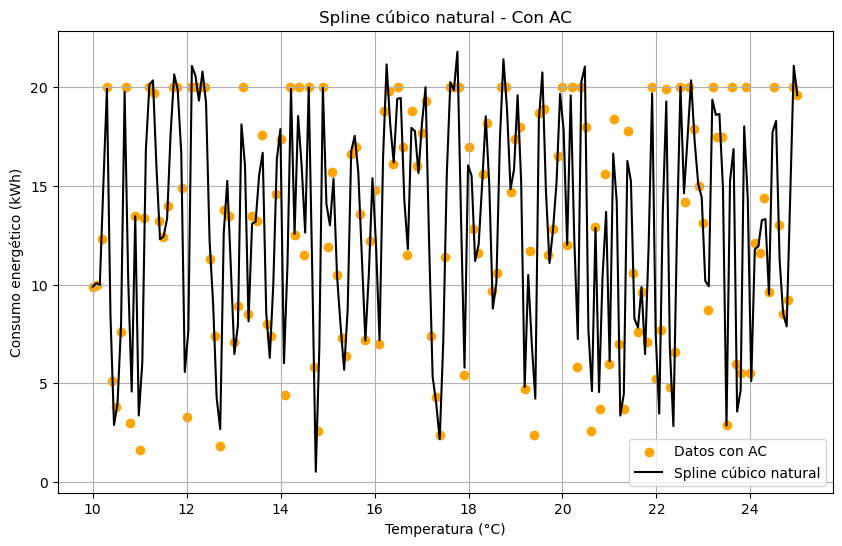

In [20]:
import matplotlib.pyplot as plt


x_interp = np.linspace(x.min(), x.max(), 200)
y_interp = [evaluar_spline(xi, x, a, b, c, d) for xi in x_interp]

# Graficar

plt.figure(figsize=(10,6))
plt.scatter(x, y, color='orange', label='Datos con AC')
plt.plot(x_interp, y_interp, color='black', label='Spline cúbico natural')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Consumo energético (kWh)')
plt.title('Spline cúbico natural - Con AC')
plt.legend()
plt.grid(True)
plt.show()


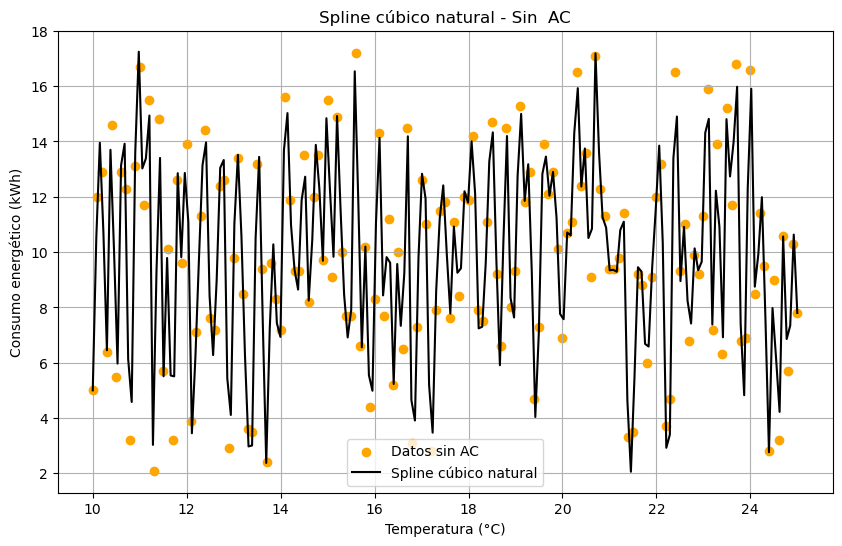

In [21]:
x_interp1 = np.linspace(x1.min(), x1.max(), 200)
y_interp1 = [evaluar_spline(xi, x1, a1, b1, c1, d1) for xi in x_interp1]

# Graficar

plt.figure(figsize=(10,6))
plt.scatter(x1, y1, color='orange', label='Datos sin AC')
plt.plot(x_interp1, y_interp1, color='black', label='Spline cúbico natural')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Consumo energético (kWh)')
plt.title('Spline cúbico natural - Sin  AC')
plt.legend()
plt.grid(True)
plt.show()


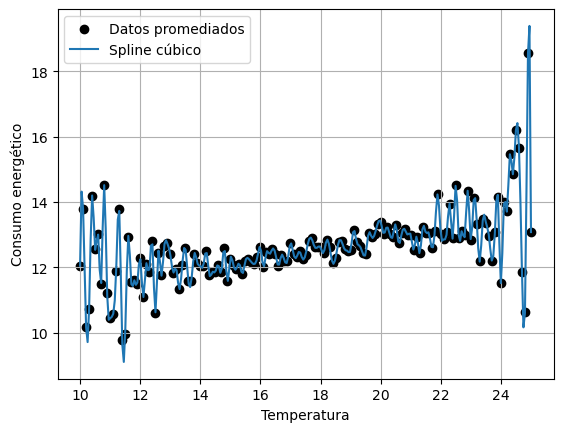

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# 1️⃣ Cargar dataset
datos = pd.read_csv('../Dataset/household_energy_consumption.csv')

# 2️⃣ Filtrar hogares con aire acondicionado
datos_aire = datos[datos['Has_AC'] == 'Yes']

# 3️⃣ Seleccionar columnas
df = datos_aire[['Avg_Temperature_C', 'Energy_Consumption_kWh']]

# 4️⃣ Limpiar datos
df = df.dropna()

# 🔴 PASO CLAVE: eliminar x repetidos
df = df.groupby('Avg_Temperature_C', as_index=False).mean()

# 5️⃣ Ordenar
df = df.sort_values('Avg_Temperature_C')

x = df['Avg_Temperature_C'].values
y = df['Energy_Consumption_kWh'].values

# 6️⃣ Crear spline cúbico
spline = CubicSpline(x, y)

# 7️⃣ Evaluar spline
x_new = np.linspace(x.min(), x.max(), 300)
y_new = spline(x_new)

# 8️⃣ Gráfica
plt.scatter(x, y, label='Datos promediados', color='black')
plt.plot(x_new, y_new, label='Spline cúbico')
plt.xlabel('Temperatura')
plt.ylabel('Consumo energético')
plt.legend()
plt.grid(True)
plt.show()


ValueError: No axis named Avg_Temperature_C for object type DataFrame